In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
# dataset
X = np.random.randn(10000, 600)
y = np.random.randint(0,5,10000)

In [5]:
Y = np.eye(5)[y]
Y.shape

(10000, 5)

In [6]:
learning_rates = [0.001,0.01,0.05,0.1,0.5]

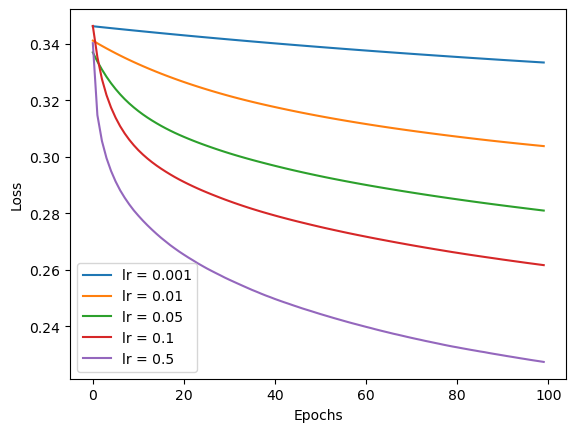

In [ ]:
for lr in learning_rates:

    # intialize weight
    W1 = np.random.randn(600, 10) * (0.01)
    b1 = np.zeros((1, 10))

    W2 = np.random.randn(10, 5)  * (0.01)
    b2 = np.zeros((1, 5))

    losses = []

    for epoch in range(100):

        # Forward Propogation
        Z1 = np.dot(X, W1) + b1
        A1 = np.maximum(0, Z1)

        Z2 = np.dot(A1, W2) + b2

        exp_val = np.exp(Z2)
        A2 = exp_val / np.sum(exp_val, axis=1, keepdims=True)  # softmax

        # loss
        loss = -np.mean(Y * np.log(A2 + 1e-8))
        losses.append(loss)

        # Back Propogation
        dZ2 = A2 - Y      # derivative of softmax is included in it
        dW2 = np.dot(A1.T, dZ2) / X.shape[0]
        db2 = np.sum(dZ2, axis=0, keepdims=True) / X.shape[0]

        dZ1 = np.dot(dZ2, W2.T) * (Z1 > 0)  # shape (10000, 10)
        dW1 = np.dot(X.T, dZ1) / X.shape[0]             # shape  (600, 10)
        db1 = np.sum(dZ1, axis = 0, keepdims=True) / X.shape[0]


        # Gradient Desecnt Update
        W1 = W1 - (lr * dW1)
        b1 = b1 - (lr * db1)

        W2 = W2 - (lr * dW2)
        b2 = b2 - (lr * db2)

    plt.plot(losses, label=f'lr = {lr}')

plt.xlabel('Epochs')
plt.ylabel("Loss")    
plt.legend()
plt.show()

In [20]:
A2.shape
dW2.shape
A2

array([[0.07139324, 0.18769483, 0.27363163, 0.14518445, 0.32209585],
       [0.53114591, 0.10164743, 0.06145044, 0.28941026, 0.01634596],
       [0.07570561, 0.35940591, 0.22905228, 0.03241202, 0.30342417],
       ...,
       [0.34730459, 0.01619317, 0.28358339, 0.18714118, 0.16577767],
       [0.13105325, 0.33273081, 0.22118913, 0.05206968, 0.26295713],
       [0.13384746, 0.04858624, 0.46239794, 0.12508269, 0.23008566]])

In [11]:
print(losses)

[np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float64(-0.3498047549832454), np.float6

In [16]:
y_pred = np.argmax(A2, axis = 1)
y_true = np.argmax(Y, axis = 1)

In [22]:
y_pred.shape

(10000,)

In [17]:
# Confusion Matrx

n_classes = Y.shape[1]
cf_matrix = np.zeros((n_classes, n_classes))

In [19]:
# filling Confusion matrix

for i, j in zip(y_pred, y_true):
    cf_matrix[i][j] += 1
print(cf_matrix)

[[1198.  178.  260.  203.  151.]
 [ 181. 1144.  255.  125.  288.]
 [ 233.  233.  941.  154.  325.]
 [ 227.  229.  222. 1304.  281.]
 [ 167.  240.  279.  278.  929.]]


In [24]:
# Accuracy
Accuracy = np.trace(cf_matrix) / np.sum(cf_matrix)

In [27]:
# Precision
Precisions = np.zeros(cf_matrix.shape[0])
for j in range(cf_matrix.shape[0]):
    Precisions[j] = cf_matrix[j][j] / np.sum(cf_matrix[:, j]) 
print(Precisions)

[0.59720837 0.56521739 0.48083802 0.63178295 0.47061803]


In [26]:
# Recall
Recall = np.zeros(cf_matrix.shape[0])
for j in range(cf_matrix.shape[0]):
    Recall[j] = cf_matrix[j][j] / np.sum(cf_matrix[j, :])
print(Recall)

[0.60201005 0.57400903 0.49893955 0.57622625 0.49075541]


In [33]:
# f1 score
F1_score = np.zeros(cf_matrix.shape[0])
for index in range(cf_matrix.shape[0]):
    
    F1_score[j] = (2 * Precisions[j] * Recall[j]) / (Precisions[j] + Recall[j])

print(F1_score)

[0.         0.         0.         0.         0.48047582]
